<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Javiera Arévalo D.
- Nombre de alumno 2: Laura Maldonado L.

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/lauraflm/MDS7202-Laboratorio-de-Programacion-Cientifica-para-Ciencia-de-Datos)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.metrics import mean_absolute_error
from datetime import timedelta
import plotly.graph_objects as go


# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [ ]:
#Codigo Aqui

#Cargar el archivo CSV
df = pd.read_csv("energia_homero.csv")

#Mostrar las primeras filas
print(df.head())

#Tipos de datos
print(df.info())


         date  Energy_kWh
0  2016-06-01      29.691
1  2016-06-02      28.789
2  2016-06-03      19.247
3  2016-06-04      22.883
4  2016-06-05      25.195
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1498 non-null   object 
 1   Energy_kWh  1498 non-null   float64
dtypes: float64(1), object(1)
memory usage: 23.5+ KB
None


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
fig = px.line(df, x='date', y='Energy_kWh', title='Consumo de energía en la casa de Homero', labels={'date': 'Fecha','Energy_kWh': 'Consumo (kWh)'}, line_shape='linear')
fig.update_traces(line_color='pink')
fig.show()


## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [ ]:
#CODIGO AQUI

#Separar datos en entrenamiento y prueba
train = df[df['date'] <= '2020-02-29'].copy()
test = df[df['date'] > '2020-02-29'].copy()

print(f"Tamaño entrenamiento: {len(train)}")
print(f"Tamaño prueba: {len(test)}")


Tamaño entrenamiento: 1369
Tamaño prueba: 129


In [ ]:
def date_to_ordinal(X):
    return np.array(X['date'].map(pd.Timestamp.toordinal)).reshape(-1, 1)


In [ ]:
Pipeline_trend = Pipeline([
    ('date_transform', FunctionTransformer(date_to_ordinal)),
    ('linear_model', LinearRegression())])

In [ ]:
Pipeline_trend.fit(train[['date']], train['Energy_kWh'])


Pipeline(steps=[('date_transform',
                 FunctionTransformer(func=<function date_to_ordinal at 0x7c770e7ca3e0>)),
                ('linear_model', LinearRegression())])

In [ ]:
#Entrenamiento del modelo lineal
Pipeline_trend.fit(train[['date']], train['Energy_kWh'])

#Predicciones para entrenamiento y prueba
train['y_pred'] = Pipeline_trend.predict(train[['date']])
test['y_pred'] = Pipeline_trend.predict(test[['date']])
df['pred_trend'] = Pipeline_trend.predict(df[['date']])

In [ ]:
mae_train = mean_absolute_error(train['Energy_kWh'], train['y_pred'])
mae_test = mean_absolute_error(test['Energy_kWh'], test['y_pred'])

print(f"MAE (Entrenamiento): {mae_train:.2f}")
print(f"MAE (Prueba): {mae_test:.2f}")

MAE (Entrenamiento): 10.57
MAE (Prueba): 8.66


In [ ]:
print(df.columns)

Index(['date', 'Energy_kWh', 'pred_trend'], dtype='object')


In [ ]:
df['error_trend'] = df['Energy_kWh'] - df['pred_trend']

fig = px.line(df, x='date', y='error_trend',
              title='Error (Real − Pred de Tendencia)',
              labels={'error_trend': 'Error'})

fig.update_traces(line_color='pink')

fig.show()


Observando el gráfico, se visualiza que los errores (Real – Predicción de Tendencia) siguen un patrón (cíclico) que se repite aproximadamente cada año. Esto se ve en que los peaks y valles más pronunciados ocurren en las mismas épocas, esto se evidencia por ejemplo en los aumentos durante los meses de mitad de año y disminuciones hacia finales de año.
Cabe mencionar que esto se repite de forma estable entre 2016-2020, por lo que la serie si presenta un comportamiento estacional, muy relacionado con invierno y el uso de calefacción, mientras que los valles se dan en meses de verano.

Para modelar la estacionalidad del consumo energético de Homero, se seleccionó un periodo
P=365 y n=3 términos de Fourier. Dado que la serie presenta fluctuaciones amplias que se repiten año a año, asociadas a los cambios de estación (mayor consumo en invierno y menor en verano), el patrón anual resulta el más representativo. Este captura adecuadamente estas oscilaciones de largo plazo, reflejando los ciclos recurrentes del consumo energético. Se observa que la línea predicha sigue el mismo comportamiento de la serie real, con incrementos y descensos en los mismos periodos del año, lo que evidencia que la estacionalidad anual fue modelada de manera efectiva y mejora el ajuste global del modelo.

In [ ]:

def fourier_terms(X, P=365, n=3):
    t = (X['date'] - X['date'].min()).dt.total_seconds() / (24*3600)
    t = np.asarray(t)
    feats = []
    for k in range(1, n+1):
        feats.append(np.sin(2*np.pi*k*t/P))
        feats.append(np.cos(2*np.pi*k*t/P))
    return np.column_stack(feats)

Pipeline_seasonal = Pipeline([
    ('fourier', FunctionTransformer(fourier_terms, kw_args={'P': 365, 'n': 3})),
    ('linear', LinearRegression())
])




In [ ]:
cutoff = pd.Timestamp('2020-02-29')

In [ ]:
#Residuo de tendencia
df['res_trend'] = df['Energy_kWh'] - df['pred_trend']

#Entrenamiento estacional sobre el train
res_train = df.loc[df['date'] <= cutoff, 'res_trend']
dates_train = df.loc[df['date'] <= cutoff, ['date']]
Pipeline_seasonal.fit(dates_train, res_train)

#Predicciones
df['pred_season'] = Pipeline_seasonal.predict(df[['date']])

#Predicción final (Tendencia + Estacionalidad)
df['pred_final'] = df['pred_trend'] + df['pred_season']

#MAE
train_mask = df['date'] <= cutoff
test_mask  = df['date'] >  cutoff

mae_train_final = mean_absolute_error(df.loc[train_mask, 'Energy_kWh'],
                                      df.loc[train_mask, 'pred_final'])
mae_test_final  = mean_absolute_error(df.loc[test_mask,  'Energy_kWh'],
                                      df.loc[test_mask,  'pred_final'])

print(f"MAE (Trend+Season | Train): {mae_train_final:.4f}")
print(f"MAE (Trend+Season | Test) : {mae_test_final:.4f}")

MAE (Trend+Season | Train): 5.6210
MAE (Trend+Season | Test) : 5.9910


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Línea real (roja)
fig.add_trace(go.Scatter(
    x=df['date'],
    y=df['Energy_kWh'],
    mode='lines',
    name='Real',
    line=dict(color='pink')
))

# Línea predicha (rosada)
fig.add_trace(go.Scatter(
    x=df['date'],
    y=df['pred_final'],
    mode='lines',
    name='Pred (Trend+Season)',
    line=dict(color='red')
))

# Títulos y etiquetas
fig.update_layout(
    title='Energy_kWh: Real vs Predicción (Tendencia + Estacionalidad)',
    xaxis_title='Fecha',
    yaxis_title='Energy_kWh'
)

fig.show()


Al mirar el gráfico se nota que el modelo con tendencia y estacionalidad anual logra seguir bastante bien el comportamiento real del consumo de Homero. La línea roja muestra subidas y bajadas suaves que coinciden con los ciclos anuales de la serie (invierno con más consumo, verano con menos).
En general, las predicciones se ajustan bien a los datos reales, especialmente en los periodos donde antes el modelo lineal fallaba más. Esto también se refleja en el MAE que es de 5.62 en entrenamiento y 5.99 en prueba, lo que indica que el modelo generaliza bien y no está sobreajustado. La diferencia entre ambos es pequeña, así que el comportamiento del modelo es bastante estable.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

**Respuesta:**

In [ ]:
#CODIGO AQUI

In [ ]:
# Limpia instalaciones previas
!pip uninstall -y -q prophet fbprophet cmdstanpy pystan numpy

# Instala versiones compatibles con Colab
!pip install -q numpy==1.26.4 cmdstanpy==1.2.0 prophet==1.1.5


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import os, sys, signal
os.kill(os.getpid(), 9)  # Fuerza el reinicio del entorno de Colab


In [ ]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import plotly.express as px
import matplotlib.pyplot as plt

#Carga de datos

df = pd.read_csv("energia_homero.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

cutoff = pd.Timestamp('2020-02-29')
train = df[df['date'] <= cutoff].copy()
test  = df[df['date'] >  cutoff].copy()

#Prophet exige columnas ds (fecha) e y (valor)
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test  = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

In [ ]:
#Modelo Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'       #'multiplicative' si hay efectos proporcionales
)
model.fit(train)

#Predicciones (test)
forecast = model.predict(test[['ds']])  #misma forma temporal que test

DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/8trlnrdi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/mgq0jd_3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13778', 'data', 'file=/tmp/tmpthxq5rr7/8trlnrdi.json', 'init=/tmp/tmpthxq5rr7/mgq0jd_3.json', 'output', 'file=/tmp/tmpthxq5rr7/prophet_model7qvpoqf_/prophet_model-20251110184801.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:48:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:48:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


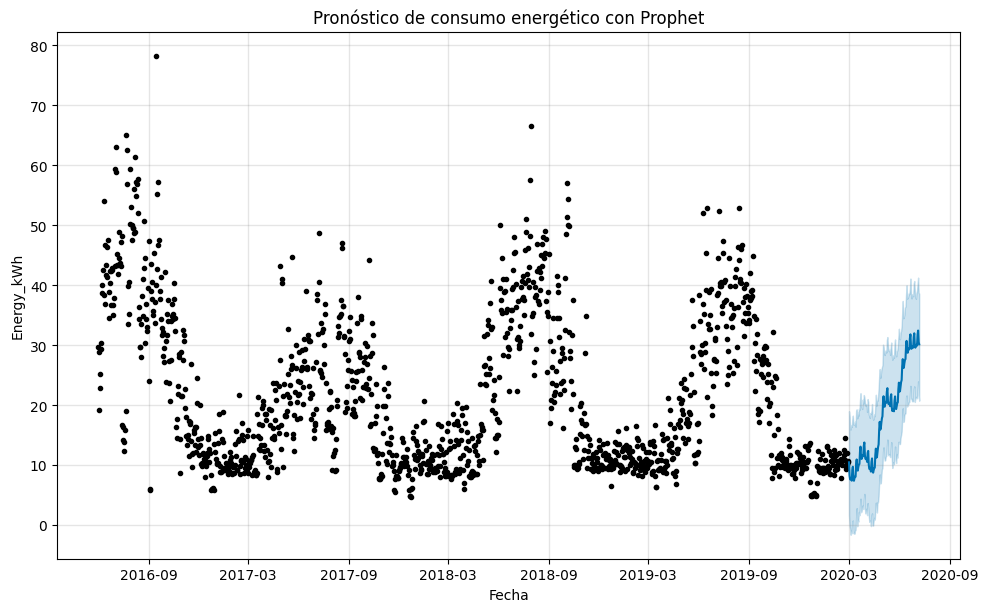

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` o

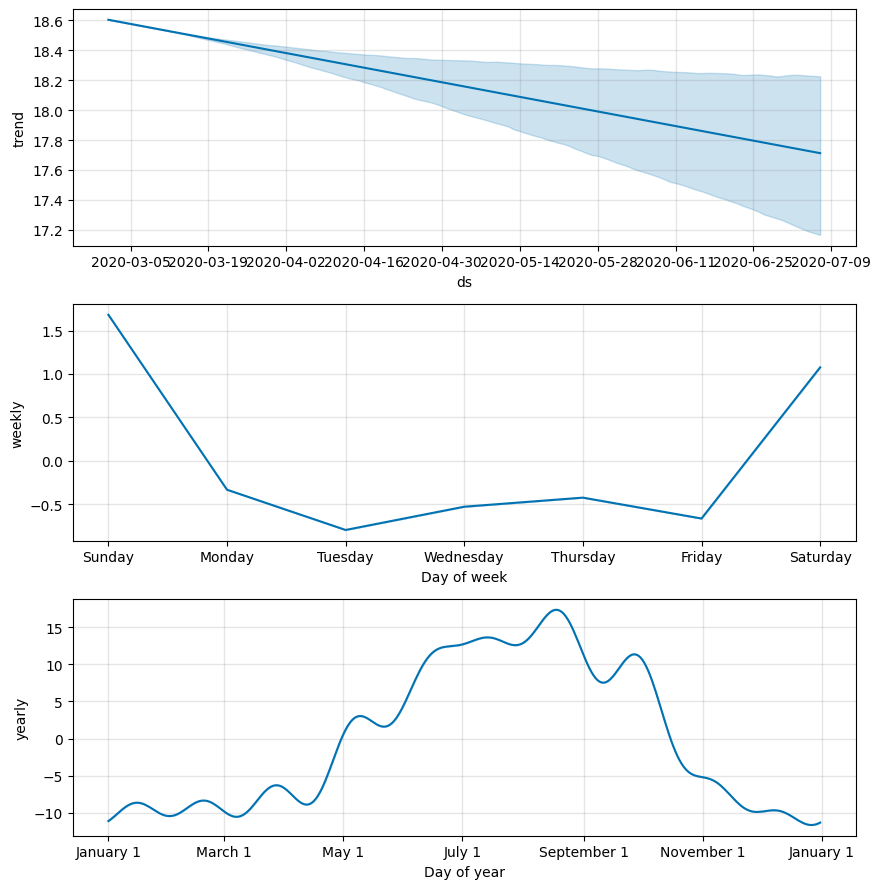

In [ ]:
#Gráficos Prophet

fig1 = model.plot(forecast)
plt.title('Pronóstico de consumo energético con Prophet')
plt.xlabel('Fecha'); plt.ylabel('Energy_kWh')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
#MAE en train y test
train_pred = model.predict(train[['ds']])

mae_train = mean_absolute_error(train['y'], train_pred['yhat'])
mae_test  = mean_absolute_error(test['y'],  forecast['yhat'])

print(f"MAE (Prophet | Train): {mae_train:.4f}")
print(f"MAE (Prophet | Test) : {mae_test:.4f}")


MAE (Prophet | Train): 4.8175
MAE (Prophet | Test) : 4.9211


Los valores de MAE son parecidos y muestran que el modelo generaliza bien y no se está sobreajustando.
Además, estos errores son menores que los del modelo lineal y al de tendencia + Fourier, por lo que podemos decir que Prophet logra capturar mejor la estacionalidad y la tendencia general del consumo de Homero.

In [ ]:
#Unir test con forecast por 'ds' y calcular el error
test_plot = (
    test[['ds', 'y']]
    .merge(forecast[['ds', 'yhat']], on='ds', how='left')
    .sort_values('ds'))

# Si por alguna razón Prophet entregó fechas repetidas, consolidamos:
# (opcional; normalmente no hace falta)
# test_plot = (test_plot
#              .groupby('ds', as_index=False)
#              .agg({'y':'first','yhat':'mean'})
#              .sort_values('ds'))

#Verificación rápida
print("Filas test:", len(test_plot))
print("NaNs en yhat:", test_plot['yhat'].isna().sum())

#Calcular error y filtrar filas válidas
test_plot['error'] = test_plot['y'] - test_plot['yhat']
test_plot = test_plot.dropna(subset=['error'])

import plotly.express as px
fig = px.line(test_plot, x='ds', y='error',
              title='Error Prophet (Real − Predicción)',
              labels={'ds': 'Fecha', 'error': 'Error'})
fig.update_traces(line_color='pink')
fig.show()


Filas test: 129
NaNs en yhat: 0


El gráfico del error no presenta un patrón claramente repetitivo ni cíclico, sino que las variaciones parecen aleatorias alrededor del cero. Esto nos dice que Prophet logró capturar adecuadamente la tendencia y la estacionalidad presentes en la serie, dejando residuos (errores) sin estructura fija.

En otras palabras, no se observa un comportamiento estacional en los errores, lo cual significa que el modelo ha explicado correctamente los componentes de la serie (tendencia y estacionalidad), y que los errores se comportan de forma más aleatoria.

Si se observa con atención, puede haber algún que otro pico aislado por ejemplo, en abril o junio, pero no hay una forma repetitiva o periódica marcada como se veía antes.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

In [ ]:
#CODIGO AQUI

In [ ]:
#Cargar datos principales (energía)
df = pd.read_csv("energia_homero.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

#Cargar datos nuevoss
meteo = pd.read_csv("datos_frink.csv")
meteo['date'] = pd.to_datetime(meteo['date'])
meteo = meteo.sort_values('date').reset_index(drop=True)

#Merge de ambos datasets (por fecha)
df_merged = pd.merge(df, meteo, on='date', how='inner')

#Verificar columnas disponibles
print("Columnas disponibles:", df_merged.columns.tolist())


Columnas disponibles: ['date', 'Energy_kWh', 'Temp_max', 'Temp_avg', 'Temp_min', 'Dew_max', 'Dew_avg', 'Dew_min', 'Hum_max', 'Hum_avg', 'Hum_min', 'Wind_max', 'Wind_avg', 'Wind_min', 'Press_max', 'Press_avg', 'Press_min']


In [ ]:
regresores = ['Temp_avg', 'Hum_avg', 'Wind_avg']

In [ ]:
cutoff = pd.Timestamp('2020-02-29')

train = df_merged[df_merged['date'] <= cutoff].copy()
test  = df_merged[df_merged['date'] >  cutoff].copy()

#Prophet necesita columnas 'ds' (fecha) y 'y' (variable objetivo)
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test  = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})


In [ ]:
from prophet import Prophet

#Crear modelo Prophet
model_reg = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

#Agregar los regresores seleccionados con el add_regressor
for var in regresores:
    model_reg.add_regressor(var)

#Entrenar modelo
model_reg.fit(train[['ds', 'y'] + regresores])


DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/svkujy7i.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/vuqoj3ji.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73109', 'data', 'file=/tmp/tmpthxq5rr7/svkujy7i.json', 'init=/tmp/tmpthxq5rr7/vuqoj3ji.json', 'output', 'file=/tmp/tmpthxq5rr7/prophet_modelhb75929d/prophet_model-20251110185722.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
forecast_reg = model_reg.predict(test[['ds'] + regresores])

#Mostrar las columnas clave
forecast_reg[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,2020-03-01,11.106068,2.318257,19.773047
1,2020-03-02,9.412227,0.891581,18.057862
2,2020-03-03,8.930650,0.651528,17.651262
3,2020-03-04,7.150151,-1.184320,15.283516
4,2020-03-05,8.569793,-0.240289,17.538432


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



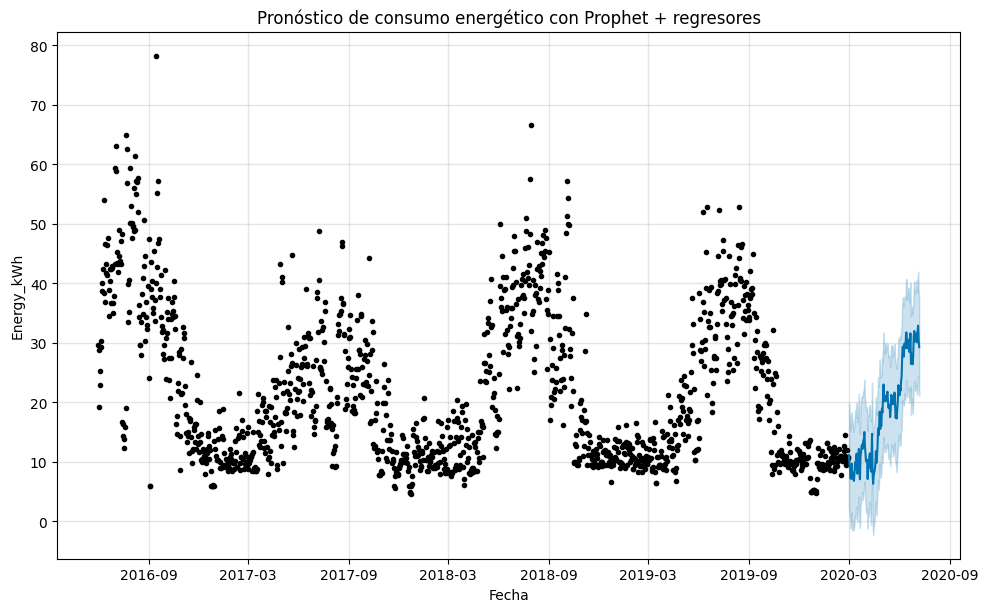

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavio

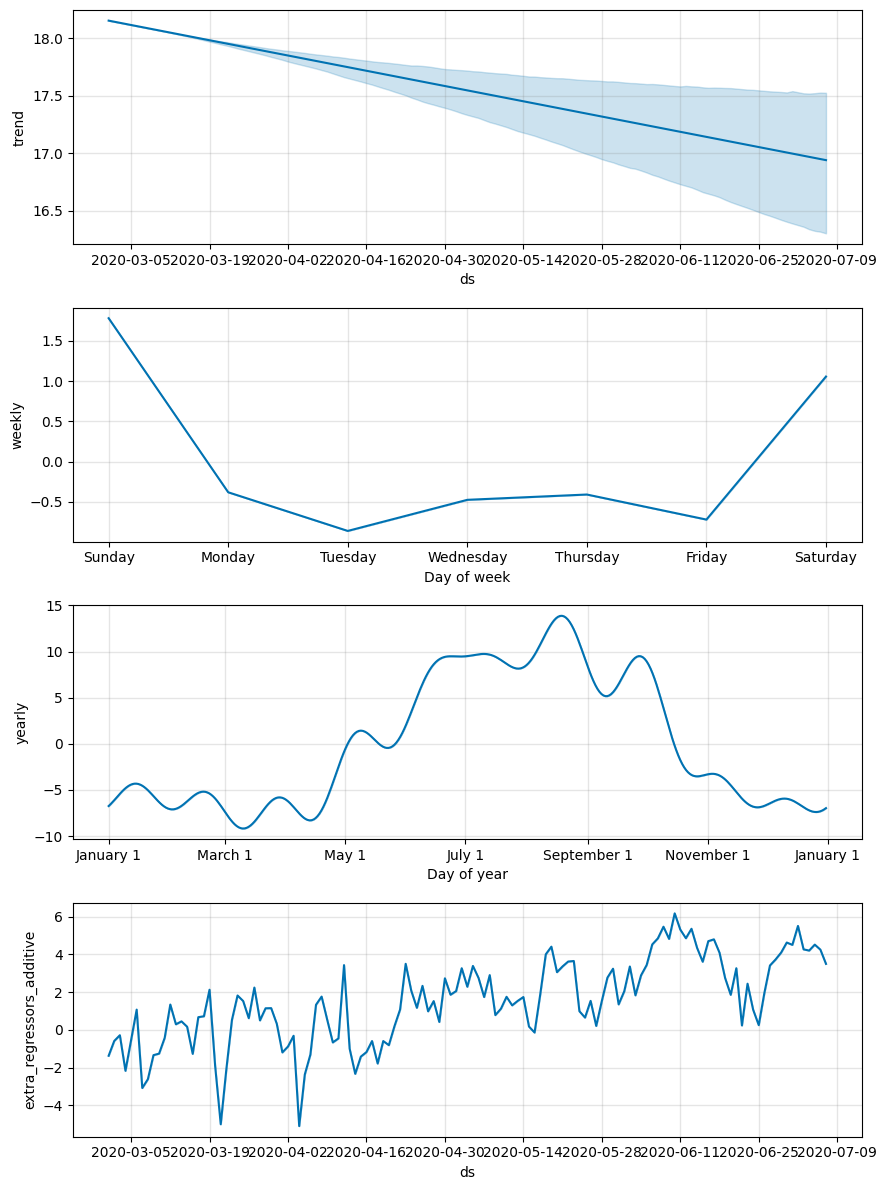

In [ ]:
#Gráfico de predicción
fig1 = model_reg.plot(forecast_reg)
plt.title('Pronóstico de consumo energético con Prophet + regresores')
plt.xlabel('Fecha')
plt.ylabel('Energy_kWh')
plt.show()

#Componentes del modelo (tendencia + estacionalidad + efecto de regresores)
fig2 = model_reg.plot_components(forecast_reg)
plt.show()


In [ ]:
#Predicciones para el conjunto de entrenamiento
train_forecast_reg = model_reg.predict(train[['ds'] + regresores])

mae_train_reg = mean_absolute_error(train['y'], train_forecast_reg['yhat'])
mae_test_reg  = mean_absolute_error(test['y'], forecast_reg['yhat'])

print(f"MAE (Prophet + regresores | Train): {mae_train_reg:.4f}")
print(f"MAE (Prophet + regresores | Test) : {mae_test_reg:.4f}")


MAE (Prophet + regresores | Train): 4.7512
MAE (Prophet + regresores | Test) : 4.5759


Al agregar regresores mejoró el desempeño frente a Prophet sin variables adicionales bajando de 5.9 a 4.7 (aproximadamente), y además el MAE de train y test son prácticamente iguales, lo cual indica una buena generalización.

In [ ]:
#Error en train
train_err = train[['ds', 'y']].merge(train_forecast_reg[['ds', 'yhat']], on='ds')
train_err['error'] = train_err['y'] - train_err['yhat']

#Error en test
test_err = test[['ds', 'y']].merge(forecast_reg[['ds', 'yhat']], on='ds')
test_err['error'] = test_err['y'] - test_err['yhat']


#Error en entrenamiento
fig_train = px.line(train_err, x='ds', y='error',
                    title='Error Prophet (Train) - Real − Predicción',
                    labels={'ds': 'Fecha', 'error': 'Error'})
fig_train.update_traces(line_color='pink')
fig_train.show()

#Error en prueba
fig_test = px.line(test_err, x='ds', y='error',
                   title='Error Prophet (Test) - Real − Predicción',
                   labels={'ds': 'Fecha', 'error': 'Error'})
fig_test.update_traces(line_color='pink')
fig_test.show()


Al agregar las variables climáticas como regresores en el modelo Prophet, el ajuste mejora y los errores son menores tanto en entrenamiento como en prueba. Los residuos ya no muestran un patrón estacional claro, lo que indica que el modelo logró capturar mejor las variaciones del consumo. Esto demuestra que las condiciones del clima sí influyen en el uso de energía en la casa de Homero, porque si hace frío y es invierno, consumirá más energía, por lo que incluir estas variables hace que las predicciones sean más precisas.


## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

In [ ]:
#CODIGO AQUI

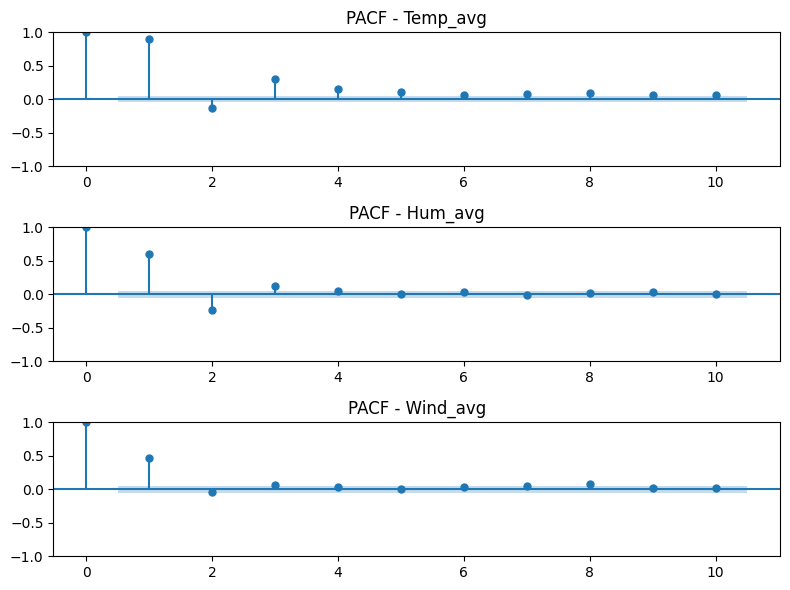

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

#Variables exógenas elegidas
exog_vars = ['Temp_avg', 'Hum_avg', 'Wind_avg']

#Gráfico de PACF para cada variable
fig, axes = plt.subplots(len(exog_vars), 1, figsize=(8, 6))
for i, var in enumerate(exog_vars):
    plot_pacf(df_merged[var], lags=10, ax=axes[i], title=f'PACF - {var}')
plt.tight_layout()
plt.show()


A partir de los gráficos de PACF de Temp_avg, Hum_avg y Wind_avg, se observa que el único rezago con autocorrelación parcial claramente significativa es el lag 1. En las tres variables, la recta en el rezago 1 está fuera de las bandas de confianza.

Por lo tanto, se decidió utilizar un lag de 1 día para cada variable exógena (Temp_avg_lag1, Hum_avg_lag1 y Wind_avg_lag1). Esto permite capturar el efecto de las condiciones meteorológicas del día anterior sobre el consumo actual, sin inflar innecesariamente la cantidad de variables y el riesgo de sobreajuste.

In [ ]:
#Crear rezagos (lags) de 1 día
for var in exog_vars:
    df_merged[f'{var}_lag1'] = df_merged[var].shift(1)

#Verificar
df_merged.head(5)


,date,Energy_kWh,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min,Temp_avg_lag1,Hum_avg_lag1,Wind_avg_lag1
0,2016-06-01,29.691,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7,NaN,NaN,NaN
1,2016-06-02,28.789,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7,74.8,89.4,9.5
2,2016-06-03,19.247,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7,71.2,96.8,7.8
3,2016-06-04,22.883,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7,72.1,93.6,4.7
4,2016-06-05,25.195,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7,71.2,96.1,7.0


In [ ]:
#Imputar NaN por la media de cada variable
for col in [f'{v}_lag1' for v in exog_vars]:
    df_merged[col] = df_merged[col].fillna(df_merged[col].mean())


In [ ]:
cutoff = pd.Timestamp('2020-02-29')

train = df_merged[df_merged['date'] <= cutoff].copy()
test  = df_merged[df_merged['date'] >  cutoff].copy()

train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test  = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})


In [ ]:

#Crear modelo Prophet
model_lags = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Agregar regresores exógenos y sus lags
for var in exog_vars:
    model_lags.add_regressor(var)
    model_lags.add_regressor(f'{var}_lag1')

# Entrenar modelo
model_lags.fit(train[['ds', 'y'] + exog_vars + [f'{v}_lag1' for v in exog_vars]])


DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/_su_desp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpthxq5rr7/kfwqpwvy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38792', 'data', 'file=/tmp/tmpthxq5rr7/_su_desp.json', 'init=/tmp/tmpthxq5rr7/kfwqpwvy.json', 'output', 'file=/tmp/tmpthxq5rr7/prophet_model8yaj8g10/prophet_model-20251110191432.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:14:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:14:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
forecast_lags = model_lags.predict(test[['ds'] + exog_vars + [f'{v}_lag1' for v in exog_vars]])
forecast_lags[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2020-03-01,11.527956,3.963120,19.890827
1,2020-03-02,9.423551,0.104262,17.350575
2,2020-03-03,9.092185,0.767607,17.167552
3,2020-03-04,7.726341,-0.185708,15.730874
4,2020-03-05,7.622084,-0.301771,16.042331


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



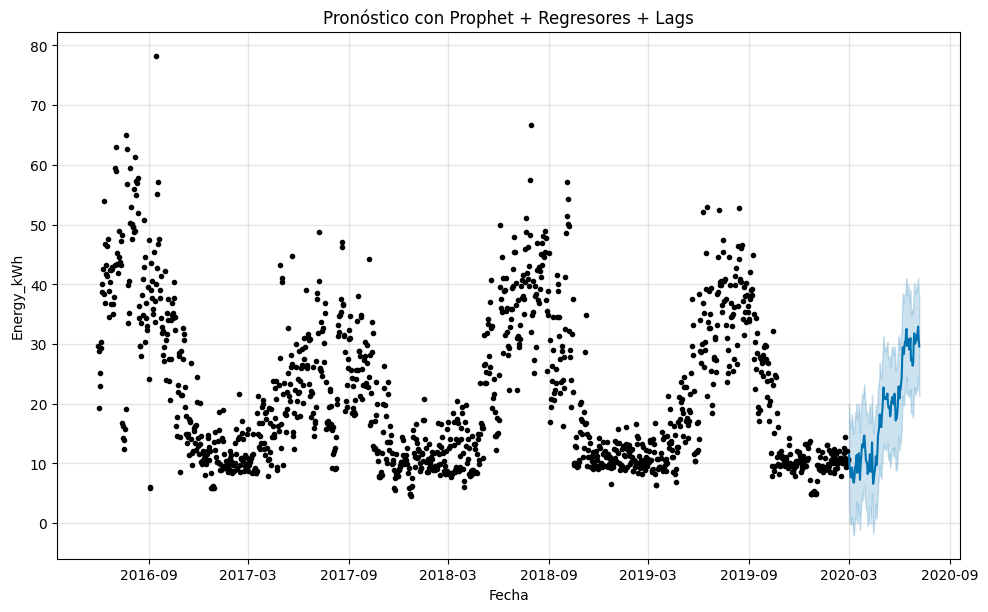

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavio

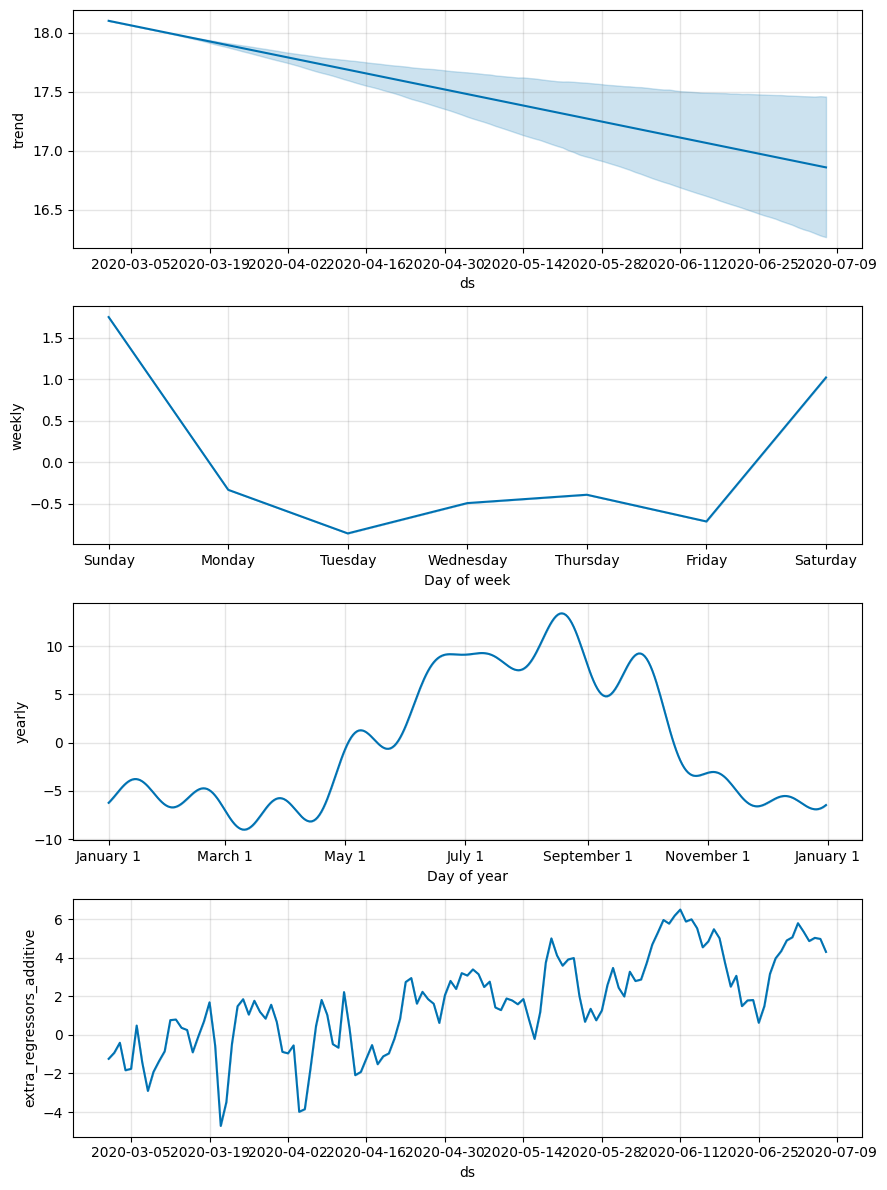

In [ ]:
# Predicciones
fig1 = model_lags.plot(forecast_lags)
plt.title('Pronóstico con Prophet + Regresores + Lags')
plt.xlabel('Fecha'); plt.ylabel('Energy_kWh')
plt.show()

# Componentes
fig2 = model_lags.plot_components(forecast_lags)
plt.show()


In [ ]:
cols_lags = ['ds'] + exog_vars + [f'{v}_lag1' for v in exog_vars]

# Predicciones entrenamiento y prueba
train_forecast_lags = model_lags.predict(train[cols_lags])
test_forecast_lags  = model_lags.predict(test[cols_lags])

# MAE train y test
mae_train_lags = mean_absolute_error(train['y'], train_forecast_lags['yhat'])
mae_test_lags  = mean_absolute_error(test['y'],  test_forecast_lags['yhat'])

print(f"MAE (Prophet + Regresores + Lags | Train): {mae_train_lags:.4f}")
print(f"MAE (Prophet + Regresores + Lags | Test) : {mae_test_lags:.4f}")


MAE (Prophet + Regresores + Lags | Train): 4.7293
MAE (Prophet + Regresores + Lags | Test) : 4.5229


Al incluir los lags de las variables meteorológicas, el modelo Prophet logró un pequeño pero consistente aumento en el rendimiento. Los nuevos valores de MAE fueron 4.73 en entrenamiento y 4.52 en prueba, ligeramente menores a los obtenidos con Prophet sin lags.
Esto indica que los lags ayudan a capturar la inercia natural del consumo energético: las condiciones climáticas del día anterior (como una temperatura baja o alta humedad) siguen influyendo en el consumo del día actual.

In [ ]:
train_plot = train[['ds', 'y']].copy()
train_plot['yhat'] = train_forecast_lags['yhat'].values
train_plot['set'] = 'Entrenamiento'

test_plot = test[['ds', 'y']].copy()
test_plot['yhat'] = test_forecast_lags['yhat'].values
test_plot['set'] = 'Prueba'

df_res_lags = pd.concat([train_plot, test_plot], ignore_index=True)
df_res_lags['error'] = df_res_lags['y'] - df_res_lags['yhat']


color_map = {
    'Entrenamiento': '#ffb6c1',  # rosado claro
    'Prueba': '#ff69b4'          # rosado fuerte
}


fig = px.line(
    df_res_lags.sort_values('ds'),
    x='ds',
    y='error',
    color='set',
    color_discrete_map=color_map,
    title='Error (Real − Predicción) Prophet con regresores y lags',
    labels={'ds': 'Fecha', 'error': 'Error', 'set': 'Conjunto'}
)


fig.update_traces(line_width=2)
fig.update_layout(
    font=dict(size=13),
    legend=dict(
        title='Conjunto',
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

El gráfico muestra un comportamiento estable y equilibrado a lo largo del tiempo. La mayoría de los errores se concentran alrededor de cero, lo que indica que el modelo no presenta sesgos sistemáticos al predecir el consumo energético. En los meses finales (marzo a julio de 2020) se observa una ligera mayor variabilidad, lo cual es normal debido a que corresponden a datos de test. En comparación con versiones anteriores, el error ya no muestra un patrón estacional tan claro, lo que significa que el modelo logró capturar de forma efectiva la tendencia y los efectos periódicos, gracias a la inclusión de los regresores climáticos y sus lags.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [ ]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [ ]:
#CODIGO AQUI

In [ ]:
#Selección de regresores
base_exogs = ['Temp_avg', 'Hum_avg', 'Wind_avg']

lag_exogs = [c for c in train.columns if c.endswith('_lag1') or c.endswith('_lag2')]

#Conjunto final de features presentes en ambos (train y test)
features = [c for c in base_exogs + lag_exogs if c in train.columns and c in test.columns]
print("Regresores considerados:", features)

#Grilla de hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],     # regularización de cambios de tendencia
    'seasonality_prior_scale': [1.0, 5.0, 10.0],     # regularización de estacionalidades
    'seasonality_mode':       ['additive', 'multiplicative'],
    'changepoint_range':      [0.8, 0.9],            # fracción inicial usada para detectar cambios
}


Regresores considerados: ['Temp_avg', 'Hum_avg', 'Wind_avg', 'Temp_avg_lag1', 'Hum_avg_lag1', 'Wind_avg_lag1']


In [ ]:
tuning_results, best_params = optimize_prophet(
    df=train[['ds','y'] + features].copy(),
    df_to_pred=test[['ds','y'] + features].copy(),
    features=features,
    param_grid=param_grid
)

display(tuning_results.head(10))  # Top-10 combinaciones por menor MAE
print("Mejores parámetros:", best_params)


Tuning Prophet parameters: 100%|██████████| 36/36 [00:19<00:00,  1.87it/s]


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,MAEs
2,0.01,1.0,multiplicative,0.8,3.970695
6,0.01,5.0,multiplicative,0.8,3.971899
3,0.01,1.0,multiplicative,0.9,3.973479
10,0.01,10.0,multiplicative,0.8,3.977623
7,0.01,5.0,multiplicative,0.9,3.982593
11,0.01,10.0,multiplicative,0.9,3.992533
9,0.01,10.0,additive,0.9,4.017225
8,0.01,10.0,additive,0.8,4.024182
1,0.01,1.0,additive,0.9,4.026148
0,0.01,1.0,additive,0.8,4.031493


Mejores parámetros: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8}


In [ ]:
best_model = Prophet(**best_params,
                     yearly_seasonality=True,
                     weekly_seasonality=True,
                     daily_seasonality=False)

for f in features:
    best_model.add_regressor(f)

best_model.fit(train[['ds','y'] + features])


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



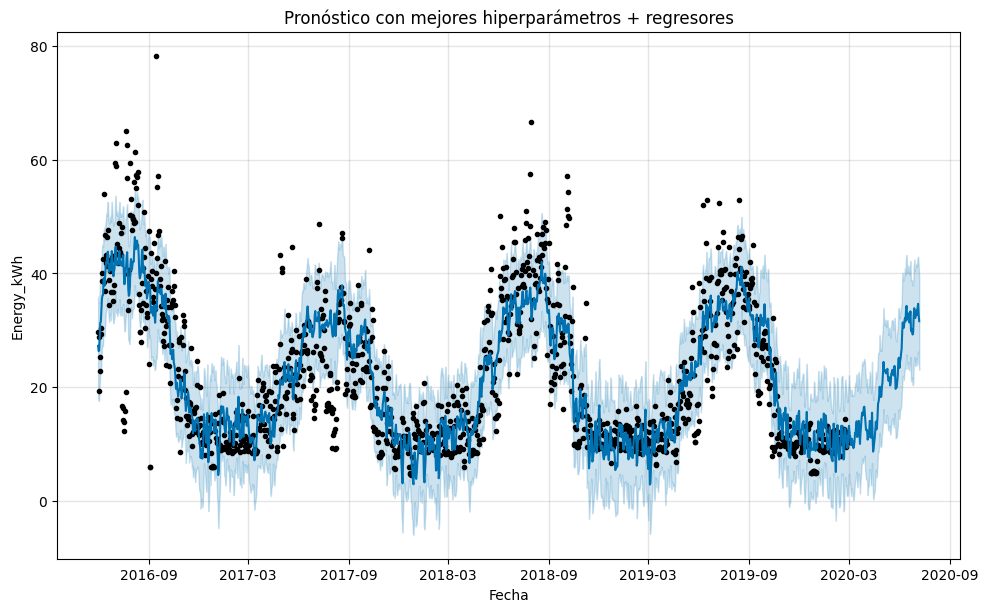

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning:

The behavio

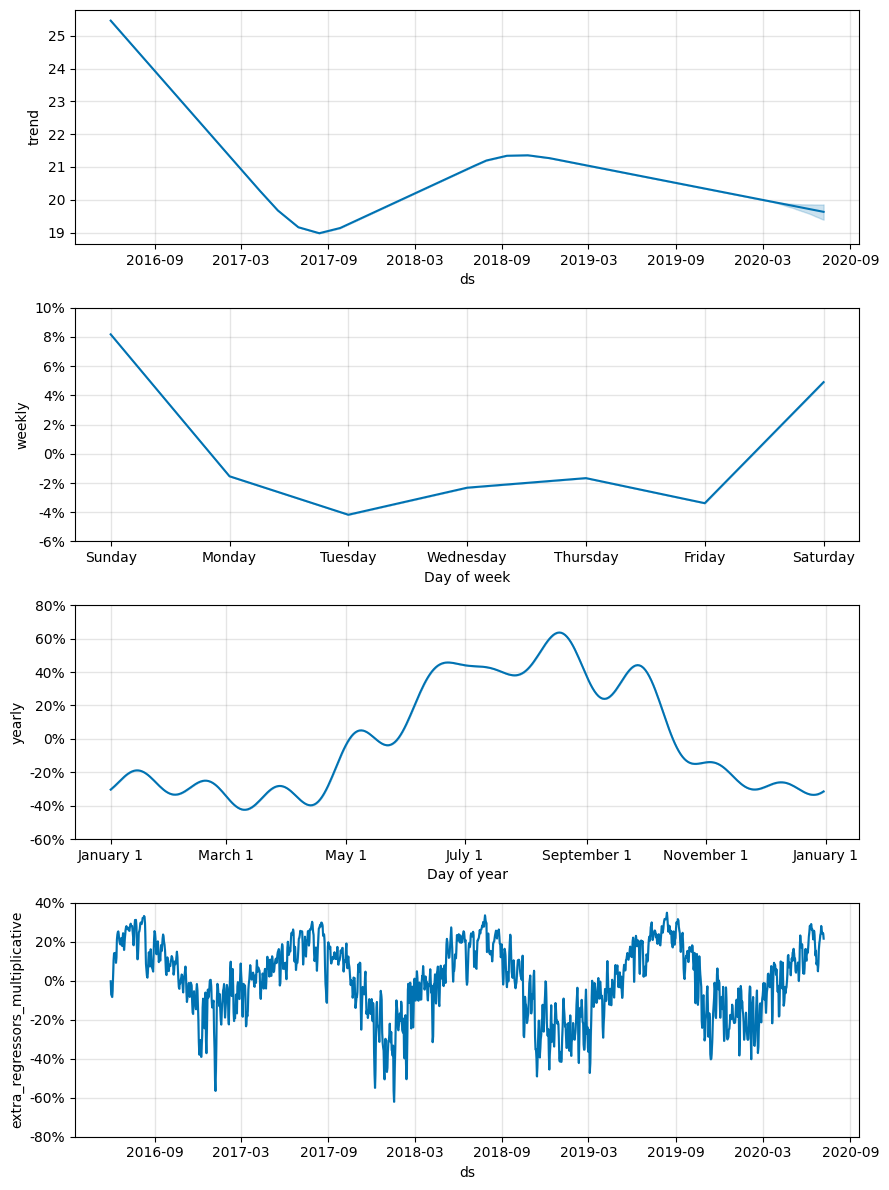

In [ ]:
#Predicción en TEST (siguiendo el patrón de tu función)
future = best_model.make_future_dataframe(periods=len(test), include_history=True)

#Ensamblamos los features de train+test en orden temporal:
X_all = pd.concat([train[features], test[features]], axis=0).reset_index(drop=True)
future[features] = X_all.values

forecast_all = best_model.predict(future)

#Cortes alineados por fechas
forecast_train = forecast_all[forecast_all['ds'].isin(train['ds'])].reset_index(drop=True)
forecast_test  = forecast_all[forecast_all['ds'].isin(test['ds'])].reset_index(drop=True)

#Gráficos Prophet
fig1 = best_model.plot(forecast_all)
plt.title('Pronóstico con mejores hiperparámetros + regresores')
plt.xlabel('Fecha'); plt.ylabel('Energy_kWh')
plt.show()

fig2 = best_model.plot_components(forecast_all)
plt.show()


In [ ]:
mae_train = mean_absolute_error(train['y'], forecast_train['yhat'])
mae_test  = mean_absolute_error(test['y'],  forecast_test['yhat'])

print(f"MAE (Train) con tuning: {mae_train:.4f}")
print(f"MAE (Test)  con tuning: {mae_test:.4f}")


MAE (Train) con tuning: 4.8225
MAE (Test)  con tuning: 3.9707


In [ ]:
#Se arman los dataframes de error por conjunto
train_err = (train[['ds','y']].merge(forecast_train[['ds','yhat']], on='ds'))
train_err['error'] = train_err['y'] - train_err['yhat']

test_err = (test[['ds','y']].merge(forecast_test[['ds','yhat']], on='ds'))
test_err['error'] = test_err['y'] - test_err['yhat']

import plotly.express as px

fig_tr = px.line(train_err, x='ds', y='error',
                 title='Error (Train) – Real − Predicción',
                 labels={'ds':'Fecha','error':'Error'})
fig_tr.update_traces(line_color='pink')

fig_tr.show()

fig_te = px.line(test_err, x='ds', y='error',
                 title='Error (Test) – Real − Predicción',
                 labels={'ds':'Fecha','error':'Error'})
fig_te.update_traces(line_color='pink')
fig_te.show()

# Mini análisis
print("Error Train — media:", train_err['error'].mean(), " | desvío:", train_err['error'].std())
print("Error Test  — media:", test_err['error'].mean(),  " | desvío:", test_err['error'].std())


Error Train — media: 0.03591726386130874  | desvío: 6.6886677658069855
Error Test  — media: 0.7218219965949975  | desvío: 5.260422184579661


Después de optimizar los hiperparámetros e incluir las variables exógenas, el modelo Prophet mejora su rendimiento. Los errores son más pequeños, se mantienen cerca de cero y ya no muestran un patrón estacional claro, lo que indica que el modelo capta bien la tendencia y los cambios del consumo energético. Además, los resultados son consistentes entre entrenamiento y prueba, por lo que el modelo generaliza bien y ofrece predicciones más precisas y estables.


# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2555142 sha256=2378ef84c42f77efff3364b12920490d8541f8c46a554801b18ffad4ac3c5b9d
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
!pip install numpy==1.26.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have

In [ ]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [ ]:
# Carga de datos
df_baron = pd.read_csv('cervezas.csv')

# shape
print(df_baron.shape)
df_baron.head()

(295059, 5)


,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA


In [ ]:
# eda breve
df_baron.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB


In [ ]:
df_baron.describe()

,userId,beerId,rating
count,295059.000000,295059.000000,295059.000000
mean,2201.510247,17498.665684,3.860367
std,4577.423286,19971.480254,0.702807
min,1.000000,5.000000,1.000000
25%,132.000000,1185.000000,3.500000
50%,293.000000,6314.000000,4.000000
75%,1141.000000,33639.000000,4.500000
max,27681.000000,75086.000000,5.000000


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [ ]:
# valores nulos
n_usuarios = df_baron["userId"].nunique()
n_productos = df_baron["beerId"].nunique()
n_calificaciones = df_baron["rating"].notna().sum()
n_missing = df_baron["rating"].isna().sum()

print("Usuarios distintos:", n_usuarios)
print("Productos distintos:", n_productos)
print("Calificaciones no nulas:", n_calificaciones)
print("Calificaciones faltantes:", n_missing)

Usuarios distintos: 706
Productos distintos: 3747
Calificaciones no nulas: 295059
Calificaciones faltantes: 0


In [ ]:
# media global de todas las calificaciones
media_rating_global = df_baron["rating"].mean()
print(f"Media global de todas las calificaciones: {media_rating_global:.3f}")

# media de calificaciones por producto
media_rating_por_producto = df_baron.groupby("beerId")["rating"].mean()

print(f"Media mínima entre productos: {media_rating_por_producto.min():.2f}")
print(f"Media máxima entre productos: {media_rating_por_producto.max():.2f}")
print(f"Media promedio de las medias por producto: {media_rating_por_producto.mean():.2f}")

Media global de todas las calificaciones: 3.860
Media mínima entre productos: 1.38
Media máxima entre productos: 4.67
Media promedio de las medias por producto: 3.79


Participaron 706 ciudadanos.
Existen 3747 cervezas distintas a partir de beerId.

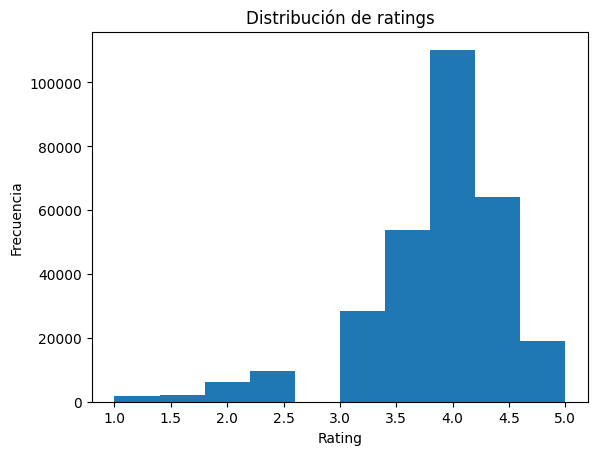

In [ ]:
# distribución de ratings
plt.figure()
df_baron["rating"].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.title("Distribución de ratings")
plt.grid(False)
plt.show()


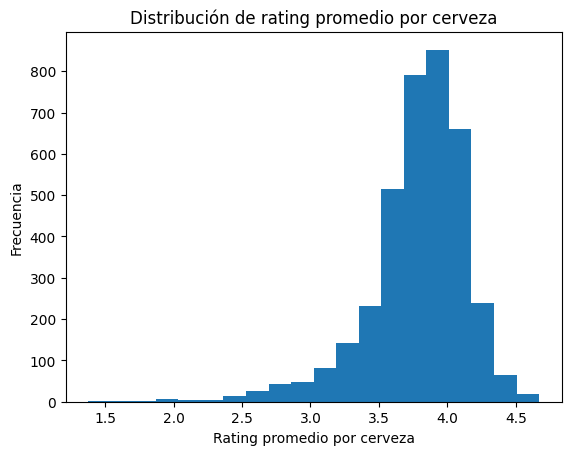

In [ ]:
# distribución de rating promedio por cerveza
media_por_producto = df_baron.groupby("beerId")["rating"].mean()

plt.figure()
media_por_producto.hist(bins=20)
plt.xlabel("Rating promedio por cerveza")
plt.ylabel("Frecuencia")
plt.title("Distribución de rating promedio por cerveza")
plt.grid(False)
plt.show()

In [ ]:
beer_stats = (
    df_baron
    .groupby(["beerId", "beerName"], as_index=False)
    .agg(
        n_ratings=("rating", "count"),
        rating_promedio=("rating", "mean")
    )
)
print(beer_stats.shape)
beer_stats

(3747, 4)


,beerId,beerName,n_ratings,rating_promedio
0,5,Amber,100,3.395000
1,6,Turbodog,230,3.765217
2,7,Purple Haze,146,3.256849
3,9,Golden,23,3.478261
4,10,Allagash Dubbel Ale,173,3.791908
...,...,...,...,...
3742,74827,Lips Of Faith - Fresh Hop India Pale Ale,25,4.100000
3743,74904,Allies Win The War!,29,3.896552
3744,74986,Lagunitas Sucks Holiday Ale,113,4.274336
3745,75013,Firestone 15 - Anniversary Ale,33,4.242424


La media general es 3.8, al realizar el análisis diferenciando por cerveza, se puede observar que se encuentran entorno a dicho valor, existiendo algunos que encuentran por sobre la media y otros bajo esta, pero sin mostrar mayores diferencias. Es posible observar esto en el gráfico de distribución anterior.

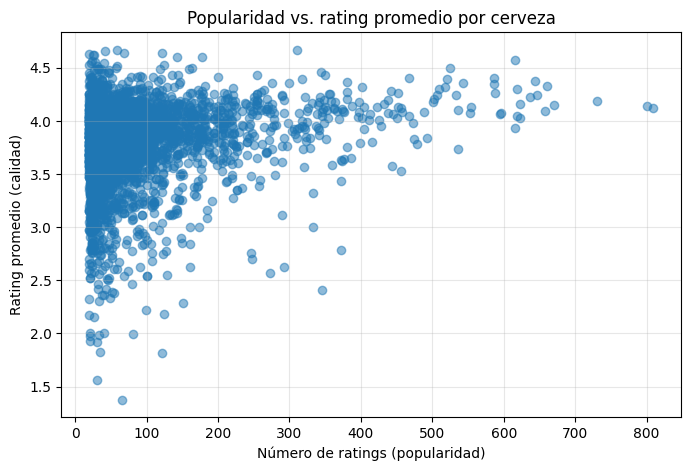

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    beer_stats["n_ratings"],
    beer_stats["rating_promedio"],
    alpha=0.5
)
plt.xlabel("Número de ratings (popularidad)")
plt.ylabel("Rating promedio (calidad)")
plt.title("Popularidad vs. rating promedio por cerveza")
plt.grid(True, alpha=0.3)
plt.show()

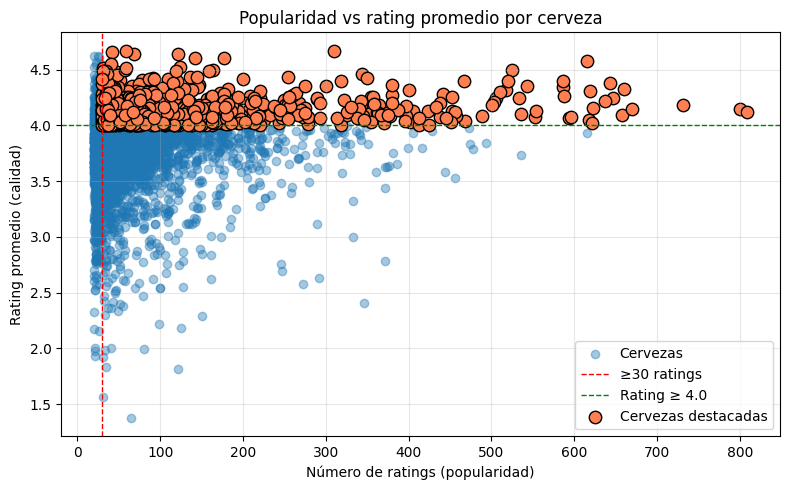

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    beer_stats["n_ratings"],
    beer_stats["rating_promedio"],
    alpha=0.4,
    label="Cervezas"
)
plt.axvline(30, color="red", linestyle="--", linewidth=1, label="≥30 ratings")
plt.axhline(4.0, color="green", linestyle="--", linewidth=1, label="Rating ≥ 4.0")

# criterioss
destacadas = beer_stats.query("n_ratings >= 30 and rating_promedio >= 4.0")

plt.scatter(
    destacadas["n_ratings"],
    destacadas["rating_promedio"],
    color="coral",
    edgecolors="black",
    s=80,
    label="Cervezas destacadas"
)

plt.xlabel("Número de ratings (popularidad)")
plt.ylabel("Rating promedio (calidad)")
plt.title("Popularidad vs rating promedio por cerveza")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Matriz usuario-producto: filas = usuarios, columnas = cervezas, valores = rating
matriz_usuario_producto = df_baron.pivot_table(
    index="userId",
    columns="beerId",
    values="rating"
)

print("Dimensión de la matriz usuario-producto:", matriz_usuario_producto.shape)
matriz_usuario_producto.head()

Dimensión de la matriz usuario-producto: (706, 3747)


beerId,5,6,7,9,10,11,14,15,17,19,...,74491,74530,74548,74579,74634,74827,74904,74986,75013,75086
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.395,3.765217,3.256849,3.478261,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,3.791908,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,3.431818,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,3.892157,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#  1 - dataframe con características por cerveza
df_cervezas = (
    df_baron[["beerId", "beerName", "beerStyle"]]
    .drop_duplicates(subset="beerId")
    .reset_index(drop=True)
)

print(df_cervezas.shape)
df_cervezas.head()

(3747, 3)


,beerId,beerName,beerStyle
0,995,Mai Bock,Maibock / Helles Bock
1,58695,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,4083,Stone Ruination IPA,American Double / Imperial IPA
3,40310,Noël Des Géants,Herbed / Spiced Beer
4,1904,Sierra Nevada Celebration Ale,American IPA


In [ ]:
# 2-  Bag of Words
df_cervezas["beerStyle"] = df_cervezas["beerStyle"].fillna("")

vect = CountVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=10
)

matriz_bow = vect.fit_transform(df_cervezas["beerStyle"])

bow_df = pd.DataFrame(
    matriz_bow.toarray(),
    index=df_cervezas.index,
    columns=vect.get_feature_names_out()
)

print(bow_df.shape)
bow_df.head()

(3747, 95)


,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 3- Matriz de similitud coseno entre cervezas
matriz_similitud = cosine_similarity(matriz_bow)
matriz_similitud

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.28867513, ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.28867513, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.33333333, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [ ]:
# 4 - Función para obtener top N cervezas similares
def top_5_similares_chocolate_porter():
    mascara = df_cervezas["beerName"].str.lower() == "chocolate porter".lower()
    if mascara.sum() == 0:
        raise ValueError("No se encontró una cerveza con nombre 'Chocolate Porter'.")

    idx = df_cervezas.index[mascara][0]
    sims = matriz_similitud[idx]
    idx_ordenados = np.argsort(sims)[::-1]
    idx_ordenados = [i for i in idx_ordenados if i != idx][:5]

    resultado = df_cervezas.loc[idx_ordenados, ["beerId", "beerName", "beerStyle"]].copy()
    resultado["similaridad"] = sims[idx_ordenados]
    print("Top 5 cervezas similares a 'Chocolate Porter':")
    display(resultado)

top_5_similares_chocolate_porter()

Top 5 cervezas similares a 'Chocolate Porter':


,beerId,beerName,beerStyle,similaridad
1381,6371,Walker's Reserve - Porter,American Porter,1.0
729,262,Saint Bridget's Porter,American Porter,1.0
2559,47747,Red Eye Coffee Porter,American Porter,1.0
3176,57466,Cowboy Coffee Porter,American Porter,1.0
3178,36341,State Pen Porter,American Porter,1.0


In [ ]:
# 5 -  Cerveza mejor evaluada por Carl (userId = 100)
ratings_carl = df_baron[df_baron["userId"] == 100]

mejor_carl = (
    ratings_carl.groupby("beerId")["rating"]
    .mean()
    .idxmax()
)

cerveza_carl = df_cervezas.loc[df_cervezas["beerId"] == mejor_carl].iloc[0]
print("Cerveza mejor evaluada por Carl:", cerveza_carl ["beerId"], "-", cerveza_carl["beerName"],"-",  cerveza_carl["beerStyle"])

Cerveza mejor evaluada por Carl: 325 - McNeill's Firehouse Amber Ale - American Amber / Red Ale


In [ ]:
# Top 5 cervezas similares según estilo
def top_5_similares_por_beerid(beer_id):
    if beer_id not in df_cervezas["beerId"].values:
        raise ValueError(f"beerId {beer_id} no existe en df_cervezas.")

    idx = df_cervezas.index[df_cervezas["beerId"] == beer_id][0]
    sims = matriz_similitud[idx]
    idx_ordenados = np.argsort(sims)[::-1]
    idx_ordenados = [i for i in idx_ordenados if i != idx][:5]

    resultado = df_cervezas.loc[idx_ordenados, ["beerId", "beerName", "beerStyle"]].copy()
    resultado["similaridad"] = sims[idx_ordenados]
    return resultado

top_similares_carl = top_5_similares_por_beerid(mejor_carl)
print("Top 5 cervezas similares a la favorita de Carl:")
top_similares_carl

Top 5 cervezas similares a la favorita de Carl:


,beerId,beerName,beerStyle,similaridad
1882,51071,Captain Sig's Northwestern Ale,American Amber / Red Ale,1.0
791,410,Ruedrich's Red Seal Ale,American Amber / Red Ale,1.0
2680,41421,Shark Attack Double Red Ale,American Amber / Red Ale,1.0
1013,6301,Stone Levitation Ale,American Amber / Red Ale,1.0
3560,3589,African Amber,American Amber / Red Ale,1.0


Todas son cervezas del mismo tipoooo

## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [ ]:
#1. Transforme el DataFrame de `pandas` a Dataset de `surprise`.
#`Hint`: Utilice solamente los identificadores de ciudadano,  cerveza y rating. ¿Importa el orden? [1 punto]
df_ratings = df_baron[["userId", "beerId", "rating"]].dropna()

# rango de valores del rating (1 a 5)
reader = Reader(rating_scale=(1, 5))

# formato surprise
data = Dataset.load_from_df(
    df_ratings.astype({"userId": str, "beerId": str}),
    reader
)

Sí. Surprise espera el orden (user, item, rating) — si  se cambia el orden, la librería interpreta mal las columnas, ya que interpreta por posición y no por nombre. Es decir que si colocaramos otro orden, la librería seguiría creyendo que la primera columna es usuario y la segunda es el id y se rompería el modelo.

In [ ]:
#2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba.
#No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]

from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.3,
    random_state=22
)

train_len = sum(1 for _ in trainset.all_ratings())
test_len = len(testset)

print(f"Tamaño trainset: {train_len}")
print(f"Tamaño testset: {test_len}")

Tamaño trainset: 206541
Tamaño testset: 88518


In [ ]:
#3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba.

sim_options_user = {
    "name": "cosine",
    "user_based": True
}

algo_knn_user = KNNBasic(sim_options=sim_options_user)

# train
algo_knn_user.fit(trainset)

# pred
predicciones_user = algo_knn_user.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [ ]:
#4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y
#muestre las predicciones en un DataFrame para su análisis.
# MAE
mae_user = accuracy.mae(predicciones_user, verbose=True)

df_pred_user = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predicciones_user],
    columns=["userId", "beerId", "rating_real", "rating_pred"]
)

print("Predicciones KNN basado en usuarios:")
df_pred_user.head()

MAE:  0.4645
Predicciones KNN basado en usuarios:


,userId,beerId,rating_real,rating_pred
0,48,156,4.0,3.850000
1,3818,38394,4.5,3.850000
2,35,38366,3.5,3.712500
3,396,27371,4.5,3.962500
4,413,49696,4.0,3.717949


In [ ]:
#5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

# repetir 3 pero para productos
sim_options_item = {
    "name": "cosine",
    "user_based": False
}

algo_knn_item = KNNBasic(sim_options=sim_options_item)

# train
algo_knn_item.fit(trainset)

# pred
predicciones_item = algo_knn_item.test(testset)

# MAE
mae_item = accuracy.mae(predicciones_item, verbose=True)

# repetir 4
df_pred_item = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predicciones_item],
    columns=["userId", "beerId", "rating_real", "rating_pred"]
)

print("Predicciones KNN basado en productos:")
df_pred_item.head()

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4640
Predicciones KNN basado en productos:


,userId,beerId,rating_real,rating_pred
0,48,156,4.0,3.850000
1,3818,38394,4.5,3.850000
2,35,38366,3.5,3.712500
3,396,27371,4.5,3.962500
4,413,49696,4.0,3.700387


In [ ]:
print(f"MAE modelo user-based:  {mae_user:.4f}")
print(f"MAE modelo item-based:  {mae_item:.4f}")

mejor_modelo = "item-based" if mae_item < mae_user else "user-based"
print(f" El modelo con mejor desempeño (menor MAE) es: {mejor_modelo}")

MAE modelo user-based:  0.4645
MAE modelo item-based:  0.4640
 El modelo con mejor desempeño (menor MAE) es: item-based


Al comparar ambos modelos mediante el MAE, vemos que tienen un desempeño similar y podría ser redondeado a 0.46, por lo que ninguno es objetivamente “mejor” en términos de calidad de predicción.

Sin embargo, decidimos quedarnos con item-based por su mínima mejora. Además, nos hace sentido ya que las similitudes entre ítems suelen ser más estables en el tiempo que las similitudes entre usuarios.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [ ]:
#Entrene un modelo NMF , asegurándose de fijar la semilla para reproducibilidad.
#Luego genere predicciones para el conjunto de prueba. [2 puntos]
from surprise import NMF, accuracy

# train
nmf = NMF(random_state=22)
nmf.fit(trainset)

# pred sobre testset
predicciones_nmf = nmf.test(testset)

In [ ]:
#Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
mae_nmf = accuracy.mae(predicciones_nmf, verbose=True)

# df análisis
df_pred_nmf = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predicciones_nmf],
    columns=["userId", "beerId", "rating_real", "rating_pred_nmf"]
)

print("Predicciones modelo NMF:")
df_pred_nmf.head()

MAE:  0.4805
Predicciones modelo NMF:


,userId,beerId,rating_real,rating_pred_nmf
0,48,156,4.0,3.865724
1,3818,38394,4.5,3.887505
2,35,38366,3.5,3.699668
3,396,27371,4.5,4.108880
4,413,49696,4.0,3.780935


In [ ]:
#Entrene un modelo SVD sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
from surprise import SVD

# Entrenamos el modelo SVD
svd = SVD(random_state=22)
svd.fit(trainset)

# Predicciones sobre el conjunto de prueba
predicciones_svd = svd.test(testset)

In [ ]:
#Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
mae_svd = accuracy.mae(predicciones_svd, verbose=True)

# df para svd análisis
df_pred_svd = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predicciones_svd],
    columns=["userId", "beerId", "rating_real", "rating_pred_svd"]
)

print("Predicciones modelo SVD:")
df_pred_svd.head()

MAE:  0.4614
Predicciones modelo SVD:


,userId,beerId,rating_real,rating_pred_svd
0,48,156,4.0,3.859040
1,3818,38394,4.5,3.918288
2,35,38366,3.5,3.684969
3,396,27371,4.5,4.030583
4,413,49696,4.0,3.700873


In [ ]:
#Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]
print(f"MAE NMF: {mae_nmf:.4f}")
print(f"MAE SVD: {mae_svd:.4f}")

MAE NMF: 0.4805
MAE SVD: 0.4614


In [ ]:
modelo_seleccionado = svd

En este inciso, podemos ver que el desempeño de SVD es claramente superior, con un MAE aproximado de 0.46 frente a NMF con 0.48, esto nos muestra que el primer modelo tiene una mejor capacidad para predecir los ratings de los usuarios.
Nosotras creemos que esto se debe a que SVD utiliza técnicas como corrección de sesgos y regularización, lo que se refleja en una mejor generalización.  

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [ ]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [ ]:
#Implemente la función get_top_n() que le permita extraer las N mejores cervezas recomendadas para cada
#ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior.
# Luego obtenga las 3 mejores cervezas recomendadas para Carl (userId = 100).
#Hint: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
from collections import defaultdict

def get_top_n(predictions, n=10, min_rating=0.0):
    top_n = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        if est >= min_rating:
            top_n[uid].append((iid, est))

    # ordenar y dejar solo las top n por usuario, eliminando duplicados de iid
    top_n_limpio = dict()
    for uid, user_ratings in top_n.items():
        # ordenar por estimación descendente
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        vistos = set()
        lista_filtrada = []
        for iid, est in user_ratings:
            if iid not in vistos:
                vistos.add(iid)
                lista_filtrada.append((iid, est))
            if len(lista_filtrada) >= n:
                break
        top_n_limpio[uid] = lista_filtrada

    return top_n_limpio

# Top 3 para Carl (en surprise los ids son strings)
top_n = get_top_n(predicciones_svd, n=3, min_rating=0.0)

top_3_carl = top_n.get("100", [])
print("Top 3 cervezas recomendadas para Carl (userId = 100):")
top_3_carl

Top 3 cervezas recomendadas para Carl (userId = 100):


[('1393', 3.9892545447824803),
 ('325', 3.84893950751465),
 ('1814', 3.8139877525399983)]

In [ ]:
df_cervezas_unicas = df_baron[["beerId", "beerName", "beerStyle"]].drop_duplicates("beerId")

recs_carl_df = pd.DataFrame(top_3_carl, columns=["beerId", "rating_pred"])
recs_carl_df["beerId"] = recs_carl_df["beerId"].astype(df_cervezas_unicas["beerId"].dtype)

recs_carl_merged = recs_carl_df.merge(df_cervezas_unicas, on="beerId", how="left")
recs_carl_merged


,beerId,rating_pred,beerName,beerStyle
0,1393,3.989255,McNeill's Extra Special Bitter,Extra Special / Strong Bitter (ESB)
1,325,3.848940,McNeill's Firehouse Amber Ale,American Amber / Red Ale
2,1814,3.813988,McNeill's Pullman's Porter,American Porter


In [ ]:
#Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl,
#para estimar las calificaciones que Carl podría darles. [1 punto]

# evaluadas por carl
cervezas_carl = df_baron.loc[df_baron["userId"] == 100, "beerId"].unique()

# todas las cervecitas
todas_cervezas = df_baron["beerId"].unique()

# entonces las no evaludas ->> son la diferencia entre los datasets
cervezas_no_carl = np.setdiff1d(todas_cervezas, cervezas_carl)

# 5 cervecitas al azar
np.random.seed(22)
muestra_5 = np.random.choice(cervezas_no_carl, size=5, replace=False)

preds_muestra_carl = []
for beer_id in muestra_5:
    pred = svd.predict(str(100), str(beer_id))
    preds_muestra_carl.append((int(pred.iid), pred.est))

df_preds_muestra_carl = pd.DataFrame(preds_muestra_carl, columns=["beerId", "rating_pred"])
df_preds_muestra_carl = df_preds_muestra_carl.merge(df_cervezas_unicas, on="beerId", how="left")
df_preds_muestra_carl

,beerId,rating_pred,beerName,beerStyle
0,46955,3.844291,Satsuma Harvest Wit,Witbier
1,4033,3.841473,Dinkel Acker Cd-Pils,German Pilsener
2,18487,3.801156,Iowa Pale Ale,American Pale Ale (APA)
3,2013,4.132179,Hitachino Nest White Ale,Witbier
4,60886,3.735477,Deliverance,American Strong Ale


In [ ]:
#Calcule los promedios de precisión@k y el recall@k para k=10 y threshold = 3.5.
#Analice sus resultados. ¿Es un buen modelo? Hint: Utilice la función dada precision_recall_at_k(...). [1 punto]

precisions_10, recalls_10 = precision_recall_at_k(
    predicciones_svd,
    k=10,
    threshold=3.5
)

precision_prom_10 = np.mean(list(precisions_10.values()))
recall_prom_10 = np.mean(list(recalls_10.values()))

print(f"Precision@10 promedio: {precision_prom_10:.4f}")
print(f"Recall@10 promedio:    {recall_prom_10:.4f}")

Precision@10 promedio: 0.7437
Recall@10 promedio:    0.3425


Los resultados son buenos y nos muestran un buen modelo. Dentro de las 10 recomendaciones, una gran proporción corresponde efectivamente a cervezas que el usuario considera relevantes (rating ≥ 3.5). Es decir, el modelo es bastante acertado al seleccionar qué items recomendar (precision). Sin embargo, el recall sugiere que el modelo no logra recuperar todos los items relevantes que podrían interesarle al usuario.

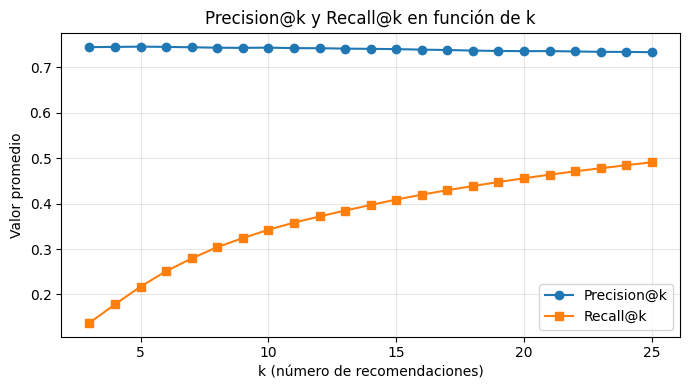

In [ ]:
#Calcule la precisión@k y el recall@k para valores de k que varíen entre 3 y 25 con paso de 1 unidad.
#Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de k. [1 punto]
ks = list(range(3, 26))
resultados_k = []

for k in ks:
    precisions_k, recalls_k = precision_recall_at_k(
        predicciones_svd,
        k=k,
        threshold=3.5
    )
    precision_prom = np.mean(list(precisions_k.values()))
    recall_prom = np.mean(list(recalls_k.values()))
    resultados_k.append((k, precision_prom, recall_prom))

df_resultados_k = pd.DataFrame(resultados_k, columns=["k", "precision", "recall"])
df_resultados_k.head()


# grafiquito

plt.figure(figsize=(7,4))
plt.plot(df_resultados_k["k"], df_resultados_k["precision"], marker="o", label="Precision@k")
plt.plot(df_resultados_k["k"], df_resultados_k["recall"], marker="s", label="Recall@k")
plt.xlabel("k (número de recomendaciones)")
plt.ylabel("Valor promedio")
plt.title("Precision@k y Recall@k en función de k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

En el gráfico de precisión@k y recall@k podemos observar que muestra el típico comportamiento de un sistema de recomendación basado en ranking, es decir, a medida que aumenta k, la precisión tiende a disminuir  mientras que el recall aumenta.
Para valores pequeños de k como 3 o 5 el modelo recomienda muy pocas cervezas, pero estos son en su mayoría relevantes, por lo que la precisión es alta y el recall bajo.

En cambio, a medida que k crece, se agregan más recomendaciones por usuario, mejorando el recall, pero al mismo tiempo se van incorporando cervezas que son menos relevantes, lo que hace que la precisión vaya decayendo.

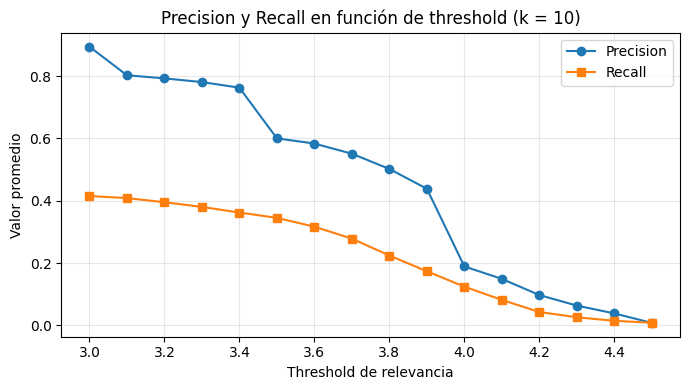

In [ ]:
#Calcule la precisión@k y el recall@k para valores de threshold que varíen entre 3.0 y 4.5, con paso de 0.1.
#Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de threshold. [1 punto]
thresholds = np.arange(3.0, 4.5 + 1e-9, 0.1)

resultados_thr = []
k_fijo = 10

for thr in thresholds:
    precisions_thr, recalls_thr = precision_recall_at_k(
        predicciones_svd,
        k=k_fijo,
        threshold=thr
    )
    precision_prom = np.mean(list(precisions_thr.values()))
    recall_prom = np.mean(list(recalls_thr.values()))
    resultados_thr.append((thr, precision_prom, recall_prom))

df_resultados_thr = pd.DataFrame(resultados_thr, columns=["threshold", "precision", "recall"])
df_resultados_thr.head()

# grafiquito
plt.figure(figsize=(7,4))
plt.plot(df_resultados_thr["threshold"], df_resultados_thr["precision"], marker="o", label="Precision")
plt.plot(df_resultados_thr["threshold"], df_resultados_thr["recall"], marker="s", label="Recall")
plt.xlabel("Threshold de relevancia")
plt.ylabel("Valor promedio")
plt.title(f"Precision y Recall en función de threshold (k = {k_fijo})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

En primer lugar, podemos observar que la precisión disminuye  a medida que el threshold aumenta. Esto ocurre porque, al exigir ratings más altos para considerar una cerveza como relevante, se vuelve más difícil que las recomendaciones coincidan exactamente con esos las que son altamente valoradas.

Para thresholds bajos (entre 3.0 y 3.3), la precisión es alta y supera el 0.80, indicando que el modelo logra acertar de forma consistente qué productos serían relevantes según un criterio más flexible. Sin embargo, cuando el threshold se acerca a 4.0, la precisión cae bruscamente, y por sobre 4.2 prácticamente desaparece, reflejando la dificultad del modelo para identificar correctamente cervezas  con ratings extremadamente altos.

Por otra parte, el recall también decrece a medida que aumenta el threshold, aunque su descenso es mucho más suave. Esto sucede porque un threshold más alto reduce el número total de cervezas consideradas relevantes para cada usuario.

Para thresholds cercanos a 3.0, el recall supera el 0.40, mientras que cerca de 4.0 baja a alrededor de 0.15, y por sobre 4.3 prácticamente llega a cero.


In [ ]:
#Finalmente utilice el mejor modelo para estimar los ratings faltantes.
#Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]
usuarios = df_baron["userId"].unique()
cervezas = df_baron["beerId"].unique()

matriz_estimada = pd.DataFrame(
    index=usuarios,
    columns=cervezas,
    dtype=float
)

for u in usuarios:
    for i in cervezas:
        est = svd.predict(str(u), str(i)).est
        matriz_estimada.loc[u, i] = est

print(matriz_estimada.shape)
matriz_estimada.head()

(706, 3747)


,995,58695,4083,40310,1904,409,16858,25061,14309,13906,...,1145,708,45308,25095,4957,47589,62792,18432,4753,6428
144,3.928278,3.716196,3.929713,3.644477,3.929687,3.668805,3.705520,3.662610,3.691765,3.735647,...,3.770213,3.900532,3.786454,3.779378,3.912446,3.700108,3.552736,3.302964,3.727387,3.615542
63,4.185715,4.043253,4.255280,4.054309,4.251769,4.030184,4.053017,4.075532,4.003616,4.097793,...,4.104892,4.090226,4.143811,4.117759,4.186627,4.048620,3.909725,3.642279,4.126732,3.900334
147,4.044733,3.929844,4.147533,3.929478,4.126800,3.910037,3.939052,3.953142,3.894224,3.978080,...,3.972592,3.981193,4.026282,3.993730,4.061894,3.944593,3.795334,3.520238,4.015958,3.778823
4261,3.780996,3.701892,3.930334,3.603814,3.865125,3.770355,3.676536,3.665420,3.625939,3.658747,...,3.731151,3.932487,3.744698,3.848264,3.888273,3.805967,3.442809,3.109113,3.793625,3.660931
140,4.050312,3.937500,4.151495,3.930603,4.141749,3.918870,3.946026,3.959905,3.894067,3.976415,...,3.989946,3.984352,4.039492,4.006839,4.073677,3.955283,3.804186,3.525305,4.023083,3.793350


In [ ]:
matriz_estimada.isna().sum().sum()
# jiji

0

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
